In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from google.colab import files

In [7]:
tf.random.set_seed(42)
print('Tensorflow version',tf.__version__)

Tensorflow version 2.19.0


In [8]:
# Download DataSet from Kaggle.com
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 84% 137M/163M [00:00<00:00, 1.44GB/s]
100% 163M/163M [00:00<00:00, 1.37GB/s]


In [9]:
with zipfile.ZipFile('face-mask-dataset.zip','r') as zip_ref:
    zip_ref.extractall('.')


In [10]:
base_dir = 'data'
print('DataSet Folders: ', os.listdir(base_dir))

DataSet Folders:  ['with_mask', 'without_mask']


In [11]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2,
                             )
train_data = datagen.flow_from_directory(base_dir, target_size=(224,224), batch_size=32,
                                         class_mode='binary', subset='training', seed=42)

Found 6043 images belonging to 2 classes.


In [12]:
test_data = datagen.flow_from_directory(base_dir, target_size=(224,224), batch_size=32,
                                         class_mode='binary', subset='validation', seed=42)

Found 1510 images belonging to 2 classes.


In [13]:
# Creating the CNN Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, 3, activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,281 (9.90 MB)

 Trainable params: 2,595,281 (9.90 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(train_data, epochs=5, validation_data=test_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
 87/189 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - accuracy: 0.6193 - loss: 0.6691

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 155ms/step - accuracy: 0.7021 - loss: 0.5631 - val_accuracy: 0.9185 - val_loss: 0.2220
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.8813 - loss: 0.2886 - val_accuracy: 0.9172 - val_loss: 0.2111
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.8947 - loss: 0.2630 - val_accuracy: 0.9404 - val_loss: 0.1886
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.9167 - loss: 0.2121 - val_accuracy: 0.9536 - val_loss: 0.1682
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.9224 - loss: 0.1986 - val_accuracy: 0.9397 - val_loss: 0.1709


In [17]:
# Evaluate
loss, accuracy = model.evaluate(test_data)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9473 - loss: 0.1590
Loss: 0.17093360424041748
Accuracy: 0.9397351145744324


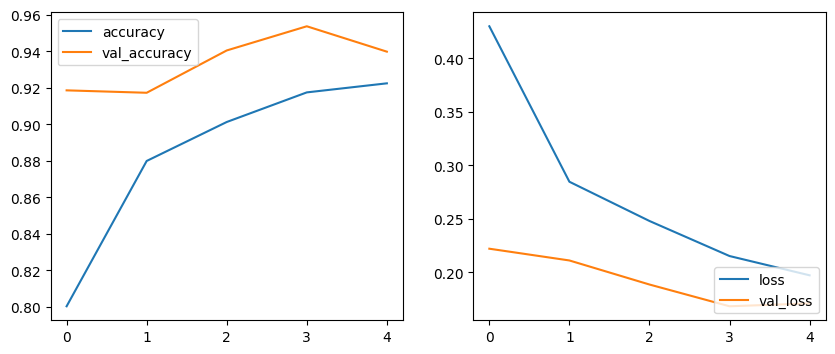

In [18]:
# plot accuracy and lost
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(loc='lower right')
plt.show()






1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step


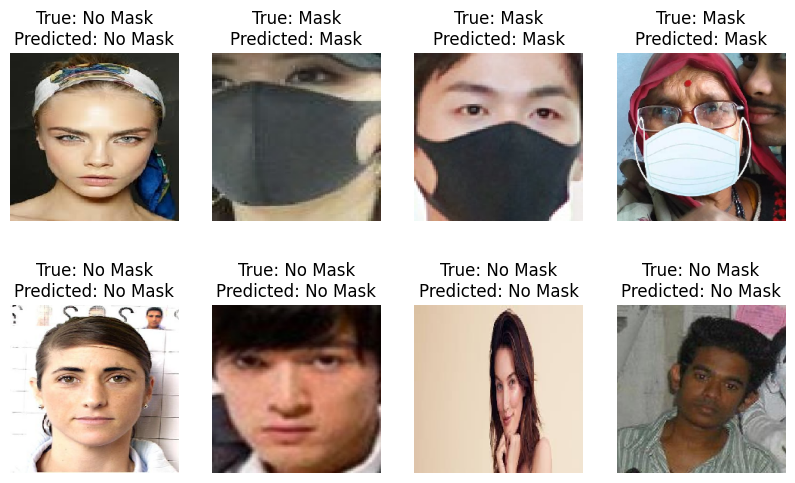

In [19]:
# Predict
images, labels = next(test_data)
predictions = model.predict(images)
plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    true_label = 'Mask' if labels[i]==0 else 'No Mask'
    predicted_label ='Mask' if predictions[i] < 0.5 else 'No Mask'
    plt.title(f"True: {true_label}\nPredicted: {predicted_label}")
    plt.axis('off')
plt.show()

Saving CR.avif to CR (1).avif
File Uploaded:  CR (1).avif
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step
Prediction: No Mask
Confidence:  (np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', np.float32(0.9913447), '%', n

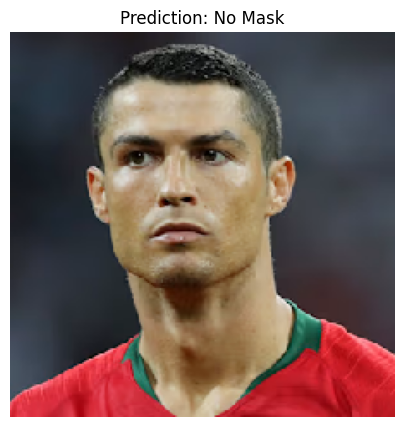

In [20]:
from matplotlib import figure
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    img_path = fn
    print('File Uploaded: ',img_path)
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

predict = model.predict(img_array)[0][0]
label = 'Mask' if predict < 0.5 else 'No Mask'
print(f'Prediction: {label}')
print('Confidence: ', 100*(1-predict) if predict < 0.5 else 100*(predict,'%'))

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f'Prediction: {label}')
plt.axis('off')
plt.show()